#### Simple MLP to test whether MBE regularization could "resolve conflict"


Given:
- Two input distributions $p_1$ and $p_2$
- Initial model parameters $\theta_0$
- Parameter shift vector $\Delta\theta$

We define:
\begin{align}
\text{Positive samples} &: \{(x, f_{\theta_0 + \Delta\theta}(x)) \mid x \sim p_1\} \\
\text{Negative samples} &: \{(x, f_{\theta_0 - \Delta\theta}(x)) \mid x \sim p_2\}
\end{align}

Where $f_{\theta}(x)$ represents the output of the model with parameters $\theta$ given input $x$. Note that two distributions should NOT be the same. 


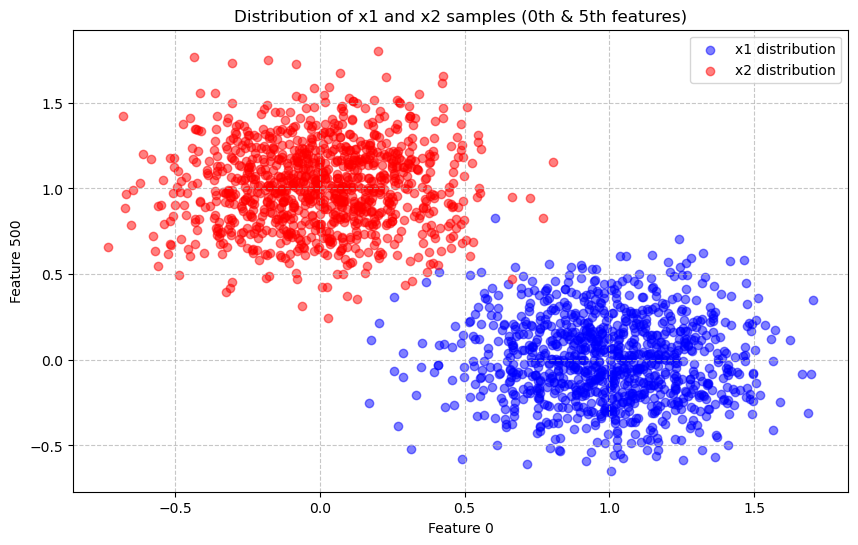

In [1]:
# initial distribution (p1 & p2)

# Define distributions p1 and p2
from src.ce_exp import sample_p1, sample_p2, plot_x1_x2

x1 = sample_p1(1000)
x2 = sample_p2(1000)
plot_x1_x2(x1, x2)


In [301]:
from src.ce_exp import * 

# Hyper-parameters 
# ------------------------------------------------------------
in_dim, hidden_dim, out_dim = 10, 20, 10 
data_size = 1000 
load_init = True
load_shift = True
exp_name = "exp_b2"
mod = "mix"
switch_phase = True

# Model initialization 
# ------------------------------------------------------------
mlp = SimpleModel(in_dim, hidden_dim, out_dim) # can we store a 'fixed' initial param, and load it every time we run experiment? 
# INIT_PARAMS_PATH = 'initial_mlp_params.pt'
# INIT_PARAMS_PATH = "mix_mlp_gapt_params.pt"
# INIT_PARAMS_PATH = "mix_mlp_params.pt"
# INIT_PARAMS_PATH = "bin/mix_mlp_params_base_1.pt"
INIT_PARAMS_PATH = "bin/mix_mlp_params_gapt_1.pt"
# INIT_PARAMS_PATH = "mix_mlp_mbe_params.pt"

if load_init: 
    mlp.load_state_dict(torch.load(INIT_PARAMS_PATH))  # Load fixed parameters
else: 
    torch.save(mlp.state_dict(), INIT_PARAMS_PATH)


# Load Original Parameters for comparison purpose
# ------------------------------------------------------------
mlp_original = SimpleModel(in_dim, hidden_dim, out_dim)
mlp_original.load_state_dict(torch.load(INIT_PARAMS_PATH))

# Build 'Conflicting' dataset
# ------------------------------------------------------------
PARAM_SHIFT_PATH = "param_shift.pkl"
if load_shift: 
    param_shift = load_param_shift(PARAM_SHIFT_PATH)
else: 
    param_shift = None 
# trainset, valset, param_shift = build_dataset(500, 100, mlp, in_dim, param_shift)


In [302]:
# Different Learning approaches 
# ------------------------------------------------------------
# (a). Train with P samples, then N samples 
# Initialize optimizer
optimizer = torch.optim.Adam(mlp.parameters(), lr=0.01)
epochs = 1000
batch_size = 32
train_accumulation_steps = batch_size // 1
val_interval = 500
val_steps = 10

# GAPT
# ------------------------------------------------------------
from src.gapt import GatedPhaseTransition
gapt = GatedPhaseTransition(p_m=125, p_a=75, tau_spike=0.1, use_softplus=False)
# ------------------------------------------------------------


# Train with positive samples first, then negative samples
# print("Training with positive samples first, then negative samples")
print("Training with positive samples")

loss_record = defaultdict(list)
frames = [] 

# Positive samples training
for epoch in range(epochs):
    group_name = decide_group_name(epoch, epochs, mod="positive")
    if epoch % val_interval == 0: 
        val_loss, similarity_metrics = validate(mlp, mlp_original, param_shift, valset, val_steps)
        for name, value in val_loss.items(): 
            loss_record[name].append(value.item())
        for name, value in similarity_metrics.items(): 
            loss_record[name].append(value)
        log_str = build_log_str(epoch, epochs, mod, val_loss, similarity_metrics)
        print(log_str)            
        frame, specialized = neuron_specialization_frame(mlp, trainset, batch_size, group_name, epoch)
        frames.append(frame)
            
    optimizer.zero_grad()

    for accum_step in range(train_accumulation_steps): 
        x_batch, y_batch = get_batch(trainset, group_name)
        
        loss_dict = mlp.compute_loss(x_batch, y_batch)
        # loss = gapt.step(loss_dict['l1'], 10.0 * loss_dict['mbe'], verbose=False)
        # loss = loss_dict["l1"]
        softness = 0.1  # controls sharpness
        soft_aux = loss_dict['mbe'].clamp(min=0.01) + softness * torch.nn.functional.softplus(
            (loss_dict['mbe'] - loss_dict['mbe'].clamp(min=0.01)) / softness
        )
        loss = loss_dict['l1'] + soft_aux

        loss.backward()
        

    optimizer.step()
    mlp.zero_grad(set_to_none=True)


Training with positive samples
 Epoch 1/1000,  | l1 positive loss: 0.0392 | mbe positive loss: 0.0425 | param shift similarity positive : 0.0000 | rep similarity positive : 0.8215 | l1 negative loss: 0.0427 | mbe negative loss: 0.0341 | param shift similarity negative : 0.0000 | rep similarity negative : 0.7722
 Epoch 501/1000,  | l1 positive loss: 0.0320 | mbe positive loss: 0.0145 | param shift similarity positive : -0.0814 | rep similarity positive : 0.8088 | l1 negative loss: 0.8163 | mbe negative loss: 0.0415 | param shift similarity negative : 0.0814 | rep similarity negative : 0.7669


In [303]:
# same pt ckpt | 'bin/mix_mlp_params_base_1.pt' | train / val data: 'bin/trainset_1.pt' / 'bin/valset_1.pt'
val_loss

# (pt ckpt | base | 1k step)
# ft base | pos 1k | l1 neg: 0.45 (0.41 0.37)
# ft gapt | pos 1k | l1 neg: 0.61 (0.66 0.64) | mbe neg: 0.10
# ft -mbe | pos 1k | l1 neg: 1.90 (much worse here)

# (pt | gapt | 1k step)
# ft base | pos 1k | l1 neg: 0.63 (0.44 0.71) 
# ft gapt | pos 1k | l1 neg: 0.77 (0.74 0.70)
# ft mbe | pos 1k | l1 neg: 0.85 (0.48 0.81)
# no clear pattern here ... 

# (pt | mbe | 1k step)


# [Concusion]. Regardless of pt strength, GAPT alone doesn't alleviate catastrophic forgetting
#              rather, it's effect in catstrophic alleviation is specific to "dataset"

{'l1_positive': tensor(0.0320),
 'mbe_positive': tensor(0.0145),
 'l1_negative': tensor(0.8163),
 'mbe_negative': tensor(0.0415)}

In [9]:
import torch 
from src.forget import * 

# --- Step 0. Load Dataset ----
# dataset with nice catastrophic forgetting alleviation behavior when adopting GAPT
good_train_path = ["bin/trainset1.pt"]
good_val_path = ["bin/valset1.pt"]

# dataset with more severe catastrophic forgetting behavior when adopting GAPT
bad_train_path = ["bin/trainset_1.pt"]
bad_val_path = ["bin/valset_1.pt"]

INIT_PARAMS_PATH = 'initial_mlp_params.pt'
PARAM_SHIFT_PATH = "param_shift.pkl"
TRAINSET_PATH = 'bin/trainset1.pt'
VALSET_PATH = "bin/valset1.pt"
data_idx = 1 
load_dataset = False


num_data = 1
num_runs = 1 

orig_model = SimpleModel(CFG['in_dim'], CFG['hidden_dim'], CFG['out_dim'])
orig_model.load_state_dict(torch.load(INIT_PARAMS_PATH))
param_shift = load_param_shift(PARAM_SHIFT_PATH)

for data_idx in range(num_data): 
    trainset, valset, param_shift = build_dataset(500, 100, orig_model, CFG['in_dim'], param_shift, shift_magnitude=0.1)
    torch.save(trainset, f"bin/trainset_{data_idx}.pt")
    torch.save(valset, f"bin/valset_{data_idx}.pt")

    # --- Step 1. Pretrain & Save ckpt ---
    # PT_PARAMS_PATH = 'mix_mlp_params.pt'
    for method_name in ["base"]: 
        for run_idx in range(num_runs): 
            pt_model = copy.deepcopy(orig_model)
            pt_loss = train_phase(pt_model, trainset, valset, orig_model, param_shift, 
                            method_name, CFG['pretrain_epochs'], train_mode="mix")
            pt_param_path = f"bin/mix_mlp_params_{method_name}_{data_idx}_{run_idx}.pt"
            torch.save(pt_model.state_dict(), pt_param_path)
            print("- Pretrained ckpt obtained")

            # --- Step 2. Finetune with different methods --- 
            pt_loss, ft_loss = run_ft_experiment(pt_param_path, trainset, valset, param_shift, orig_model, 
                                                ft_steps=1000, n_ft_runs=6, patch_size=32)
            ft_loss[f"pretrain_{method_name}"] = {k:v.item() for k,v in pt_loss.items()}
            is_bad_dataset = ft_loss['base']['l1_negative'] - ft_loss['gapt']['l1_negative']


- Dataset constructed with 600 positive & negative samples
- Pretrained ckpt obtained


In [11]:
num_data = 20
num_runs = 1
n_ft_runs = 6

orig_model = SimpleModel(CFG['in_dim'], CFG['hidden_dim'], CFG['out_dim'])
orig_model.load_state_dict(torch.load(INIT_PARAMS_PATH))
param_shift = load_param_shift(PARAM_SHIFT_PATH)

# Collect all results
all_results = []

for data_idx in range(num_data): 
    print(f"\n=== Dataset {data_idx+1}/{num_data} ===")
    trainset, valset, param_shift = build_dataset(500, 100, orig_model, CFG['in_dim'], param_shift)
    torch.save(trainset, f"bin/trainset_{data_idx}.pt")
    torch.save(valset, f"bin/valset_{data_idx}.pt")

    for method_name in ["base", "gapt"]: 
        for run_idx in range(num_runs): 
            pt_model = copy.deepcopy(orig_model)
            pt_loss = train_phase(pt_model, trainset, valset, orig_model, param_shift, 
                            method_name, CFG['pretrain_epochs'], train_mode="mix")
            pt_param_path = f"bin/mix_mlp_params_{method_name}_{data_idx}_{run_idx}.pt"
            torch.save(pt_model.state_dict(), pt_param_path)
            print(f"  PT run {run_idx+1}/{num_runs} done")

            # Finetune
            pt_loss, ft_loss = run_ft_experiment(pt_param_path, trainset, valset, param_shift, orig_model, 
                                                ft_steps=1000, n_ft_runs=n_ft_runs, patch_size=32)
            
            # Record metrics
            base_mbe_pos = ft_loss['base']['mbe_positive']
            base_l1_neg = ft_loss['base']['l1_negative']
            
            for ft_method in ['gapt', 'mbe']:
                all_results.append({
                    'data_idx': data_idx,
                    'run_idx': run_idx,
                    'init_l1_neg': pt_loss["l1_negative"], 
                    "init_mbe_neg": pt_loss["mbe_negative"],
                    'ft_method': ft_method,
                    'base_mbe_pos': base_mbe_pos,
                    'method_mbe_pos': ft_loss[ft_method]['mbe_positive'],
                    'base_l1_neg': base_l1_neg,
                    'method_l1_neg': ft_loss[ft_method]['l1_negative'],
                    'alleviation_pct': (base_l1_neg - ft_loss[ft_method]['l1_negative']) / (base_l1_neg - pt_loss["l1_negative"]) * 100,
                })

# Convert to DataFrame
import pandas as pd
df = pd.DataFrame(all_results)
df.to_csv('bin/sweep_results.csv', index=False)
print(f"\nSaved {len(df)} results to bin/sweep_results.csv")


=== Dataset 1/20 ===
- Dataset constructed with 600 positive & negative samples
  PT run 1/1 done
  PT run 1/1 done

=== Dataset 2/20 ===
- Dataset constructed with 600 positive & negative samples
  PT run 1/1 done
  PT run 1/1 done


KeyboardInterrupt: 

In [13]:
import pandas as pd 
df = pd.read_csv("bin/sweep_v3/results.csv")
df

,shift_mag,data_idx,run_idx,init_l1_neg,init_mbe_neg,ft_method,base_mbe_pos,method_mbe_pos,base_l1_neg,method_l1_neg,alleviation_pct,compression_ratio
0,0.5,0,0,0.013544,0.131559,gapt,0.122834,0.017343,0.197458,0.171260,14.244834,7.082835
1,0.5,0,0,0.013544,0.131559,mbe,0.122834,0.003961,0.197458,0.125091,39.348070,31.013852
2,0.5,1,0,0.015223,0.144561,gapt,0.138539,0.018267,0.259589,0.267349,-3.175450,7.584009
3,0.5,1,0,0.015223,0.144561,mbe,0.138539,0.004253,0.259589,0.168125,37.429118,32.574095
4,0.5,2,0,0.016964,0.114193,gapt,0.109387,0.015307,0.165211,0.147261,12.108249,7.146026
...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.5,97,0,0.014493,0.130763,mbe,0.129271,0.005692,0.161993,0.150288,7.935964,22.710742
196,0.5,98,0,0.014036,0.106505,gapt,0.121230,0.019414,0.193525,0.163752,16.587577,6.244477
197,0.5,98,0,0.014036,0.106505,mbe,0.121230,0.004562,0.193525,0.166019,15.324535,26.571716
198,0.5,99,0,0.016029,0.138456,gapt,0.161382,0.024245,0.234200,0.176311,26.533574,6.656418


In [15]:
import pandas as pd

df = pd.read_csv("bin/sweep_v3/results.csv")

# Aggregate across all datasets/runs
agg = df.groupby('ft_method').agg({
    'init_l1_neg': 'mean',
    'base_l1_neg': 'mean',
    'method_l1_neg': 'mean',
}).to_dict('index')

# Get values
init_loss = agg['gapt']['init_l1_neg']  # Same for both methods
base_ft = agg['gapt']['base_l1_neg']    # Same for both methods
gapt_ft = agg['gapt']['method_l1_neg']
mbe_ft = agg['mbe']['method_l1_neg']

# Calculate % change vs base finetune
gapt_pct = (gapt_ft - base_ft) / base_ft * 100
mbe_pct = (mbe_ft - base_ft) / base_ft * 100

# Build table
table = pd.DataFrame([{
    'Pre-training (Mix)': 'L_NLL',
    'L_NLL (Pos)': f'{init_loss:.3f}',
    'Finetune (Pos): L_NLL': f'{base_ft:.2f}',
    'Finetune (Pos): GAPT': f'{gapt_ft:.2f} ({gapt_pct:+.0f}%)',
    'Finetune (Pos): L_NLL + λ·L_MBE': f'{mbe_ft:.2f} ({mbe_pct:+.0f}%)',
}])

# Display with nice formatting
table.style.hide(axis='index')

Pre-training (Mix),L_NLL (Pos),Finetune (Pos): L_NLL,Finetune (Pos): GAPT,Finetune (Pos): L_NLL + λ·L_MBE
L_NLL,0.015,0.19,0.17 (-12%),0.17 (-13%)


In [16]:
32 **2

1024

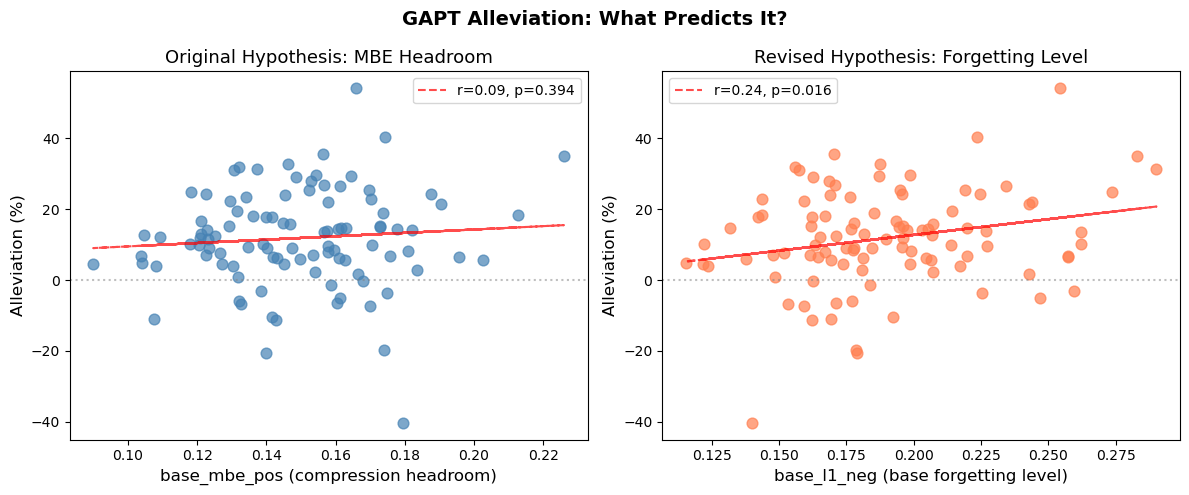

In [14]:
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

gapt_df = df[df['ft_method'] == 'gapt']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: base_mbe_pos vs alleviation ---
ax = axes[0]
ax.scatter(gapt_df['base_mbe_pos'], gapt_df['alleviation_pct'], alpha=0.7, s=60, c='steelblue')

# Regression line
x = gapt_df['base_mbe_pos']
y = gapt_df['alleviation_pct']
slope, intercept, r, p, _ = stats.linregress(x, y)
ax.plot(x, slope * x + intercept, 'r--', alpha=0.7, label=f'r={r:.2f}, p={p:.3f}')

ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('base_mbe_pos (compression headroom)', fontsize=12)
ax.set_ylabel('Alleviation (%)', fontsize=12)
ax.set_title('Original Hypothesis: MBE Headroom', fontsize=13)
ax.legend()

# --- Plot 2: base_l1_neg vs alleviation ---
ax = axes[1]
ax.scatter(gapt_df['base_l1_neg'], gapt_df['alleviation_pct'], alpha=0.7, s=60, c='coral')

# Regression line
x = gapt_df['base_l1_neg']
y = gapt_df['alleviation_pct']
slope, intercept, r, p, _ = stats.linregress(x, y)
ax.plot(x, slope * x + intercept, 'r--', alpha=0.7, label=f'r={r:.2f}, p={p:.3f}')

ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('base_l1_neg (base forgetting level)', fontsize=12)
ax.set_ylabel('Alleviation (%)', fontsize=12)
ax.set_title('Revised Hypothesis: Forgetting Level', fontsize=13)
ax.legend()

plt.suptitle('GAPT Alleviation: What Predicts It?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bin/gapt_correlation_analysis.png', dpi=150)
plt.show()

In [22]:
save_path = f"logs/{exp_name}_neuron_specialization.gif"
print(f"Saving animation to {save_path}...")
fps = 4
duration = int(1000 / fps)  # Convert fps to duration in ms
frames[0].save(
    save_path,
    save_all=True,
    append_images=frames[1:],
    optimize=False,
    duration=duration,
    loop=0
)
print(f"Animation saved successfully to {save_path}")

Saving animation to logs/exp_b2_neuron_specialization.gif...
Animation saved successfully to logs/exp_b2_neuron_specialization.gif


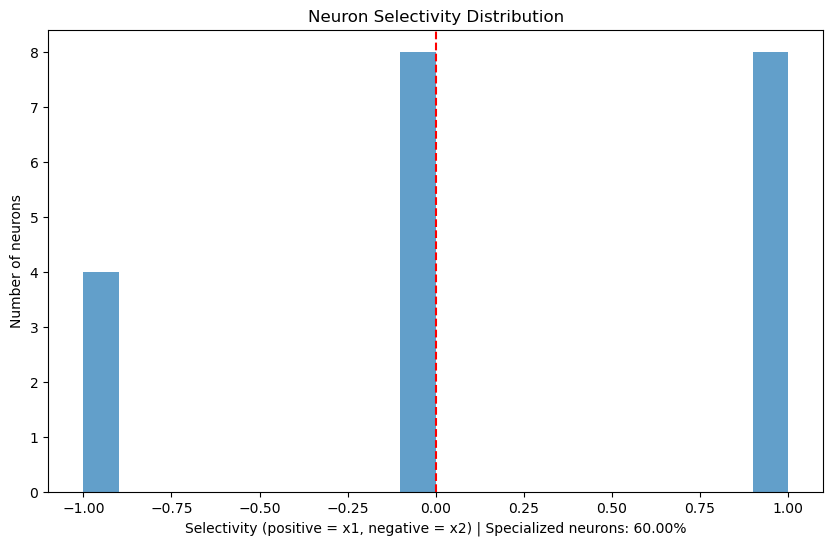

{'between_distance': 7.052892208099365, 'within_variance': 0.4852455258369446, 'separation_ratio': 10.124800682067871, 'specialized_score': 0.6000000238418579}


<Figure size 640x480 with 0 Axes>

In [101]:
from src.ce_exp import * 

# visualize_representations(mlp, valset, batch_size=32)
# visualize_representations_umap(mlp, valset, batch_size=32)
# visualize_representations_tsne(mlp, valset, batch_size=32)
separation_metrics = measure_separation(mlp, valset, batch_size=32)
specialized_score = neuron_specialization(mlp, valset, batch_size=32, save_path="logs/exp_a4_neuron_specialization.png")
separation_metrics['specialized_score'] = specialized_score
print(separation_metrics)

In [5]:
from PIL import Image
import os

# Paths to the GIF files
gif1_path = 'logs/exp_a7_neuron_specialization.gif'
gif2_path = 'logs/exp_a8_neuron_specialization.gif'
output_path = 'logs/combined_neuron_specialization.gif'

# Load the GIFs
gif1 = Image.open(gif1_path)
gif2 = Image.open(gif2_path)

# Get the number of frames in each GIF
def get_frame_count(gif):
    frames = 0
    try:
        while True:
            gif.seek(frames)
            frames += 1
    except EOFError:
        pass
    gif.seek(0)  # Reset to first frame
    return frames

n_frames1 = get_frame_count(gif1)
n_frames2 = get_frame_count(gif2)

# Use the minimum number of frames between the two GIFs
n_frames = min(n_frames1, n_frames2)

# Create new frames by combining images side by side
combined_frames = []
for i in range(n_frames):
    # Get current frames
    gif1.seek(i)
    gif2.seek(i)
    frame1 = gif1.copy().convert('RGBA')
    frame2 = gif2.copy().convert('RGBA')
    
    # Create a new image with enough width for both frames
    width = frame1.width + frame2.width
    height = max(frame1.height, frame2.height)
    combined = Image.new('RGBA', (width, height))
    
    # Paste the frames side by side
    combined.paste(frame1, (0, 0))
    combined.paste(frame2, (frame1.width, 0))
    
    combined_frames.append(combined)

# Save the combined GIF
fps = 4  # Use the same FPS as in your original code
duration = int(1000 / fps)  # Convert fps to duration in ms
combined_frames[0].save(
    output_path,
    save_all=True,
    append_images=combined_frames[1:],
    optimize=False,
    duration=duration,
    loop=0
)

print(f"Combined GIF saved to {output_path}")


Combined GIF saved to logs/combined_neuron_specialization.gif


In [2]:
import os 
import pickle 
from src.utils import plot_dual_metrics

log_dir = "logs"

plot_dual_metrics(loss_record, names=(f'l1_positive', f'l1_negative'), 
                  save_path=os.path.join(log_dir, f"{exp_name}_l1_pos_neg.png"), same_scale=True)

plot_dual_metrics(loss_record, names=(f'mbe_positive', f'mbe_negative'), 
                  save_path=os.path.join(log_dir, f"{exp_name}_mbe_pos_neg.png"), same_scale=True)

plot_dual_metrics(loss_record, names=(f'param_shift_cosine_similarity_positive', f'param_shift_cosine_similarity_negative'), 
                  save_path=os.path.join(log_dir, f"{exp_name}_param_shift_sim_pos_neg.png"), same_scale=True)

plot_dual_metrics(loss_record, names=(f'rep_cosine_similarity_positive', f'rep_cosine_similarity_negative'), 
                  save_path=os.path.join(log_dir, f"{exp_name}_rep_sim_pos_neg.png"), same_scale=True)

# save loss record 
with open(os.path.join(log_dir, f"{exp_name}_loss_record.pkl"), "wb") as f: 
    pickle.dump(loss_record, f)

Plotting metrics: l1_positive and l1_negative...
Using same scale for both axes: [0.0262, 0.7365]
- Plot saved to logs/exp_a8_l1_pos_neg.png
Plotting metrics: mbe_positive and mbe_negative...
Using same scale for both axes: [0.0147, 0.3788]
- Plot saved to logs/exp_a8_mbe_pos_neg.png
Plotting metrics: param_shift_cosine_similarity_positive and param_shift_cosine_similarity_negative...
Using same scale for both axes: [-0.0295, 0.0295]
- Plot saved to logs/exp_a8_param_shift_sim_pos_neg.png
Plotting metrics: rep_cosine_similarity_positive and rep_cosine_similarity_negative...
Using same scale for both axes: [0.4110, 0.6349]
- Plot saved to logs/exp_a8_rep_sim_pos_neg.png


In [9]:
import os, glob 

log_dir = "logs"  # Change this to your directory path if needed

# Find all PNG files
png_files = glob.glob(os.path.join(log_dir, "*.png"))
exps = ["exp_a7", "exp_a8"]
png_files = [f for f in png_files if any(exp in f for exp in exps)]
png_files.sort()  # Sort them for consistent arrangement

idx = 3
png_files[idx::4]

['logs/exp_a7_rep_sim_pos_neg.png', 'logs/exp_a8_rep_sim_pos_neg.png']